Some notes

stationary series:
- roughly horizontal + no trend
- constant varience
- no patterns predictable in the long-term + no seasonality

Preview:
- make data stationary -> build model(s) -> reverse everything -> generate forecasts 
- the action of reversing is integrating part in the ARIMA (I)

non-stationary series:
- acf of non stationary data decreases slowly

differencing help stabilize the mean.

taking the second differencing: second-order differencing.

seasonal differencing:
- is difference between an observation and the corresping observation from the previous year. 
- closer to being stationary
- if not stationary after, non-stationary can be removed with further first difference


makes no difference which is done first (seasonal and first differencing). if seasonality strong take seasonal difference 

# 9.1 Stationary and differencing

In [7]:
import pandas as pd

google = (
    pd.read_csv("../data/tsibbledata/gafa_stock.csv", parse_dates=["Date"])
    .loc[lambda x: (x["Symbol"] == "GOOG") & (x["Date"].dt.year == 2015)]
    .rename(columns={"Date": "ds", "Close": "y"})
    .assign(unique_id="GOOG_Close")
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

google

,unique_id,ds,y
0,GOOG_Close,2015-01-02,521.937744
1,GOOG_Close,2015-01-05,511.057617
2,GOOG_Close,2015-01-06,499.212799
3,GOOG_Close,2015-01-07,498.357513
4,GOOG_Close,2015-01-08,499.928864
...,...,...,...
247,GOOG_Close,2015-12-24,748.400024
248,GOOG_Close,2015-12-28,762.510010
249,GOOG_Close,2015-12-29,776.599976
250,GOOG_Close,2015-12-30,771.000000


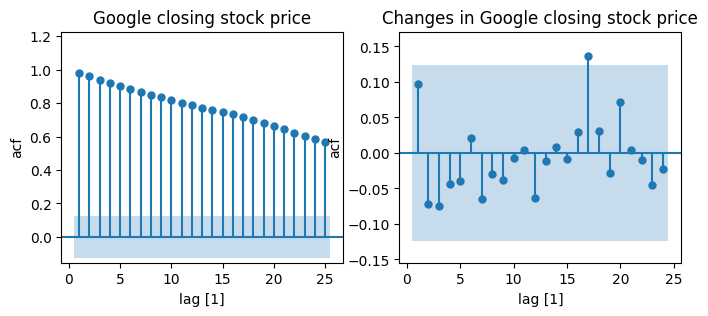

In [9]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_acf(
    google["y"], ax=axes[0], zero=False,
    title="Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
plot_acf(
    google["y"].diff().iloc[1:], ax=axes[1], zero=False,
    title="Changes in Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
for ax in axes:
    ax.set(xlabel="lag [1]", ylabel="acf")
plt.show()

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox


ljung_box = acorr_ljungbox(google["y"].diff()[1:], lags=[10])
ljung_box

,lb_stat,lb_pvalue
10,7.914143,0.637223


# 9.5 Non-seasonal ARIMA

/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


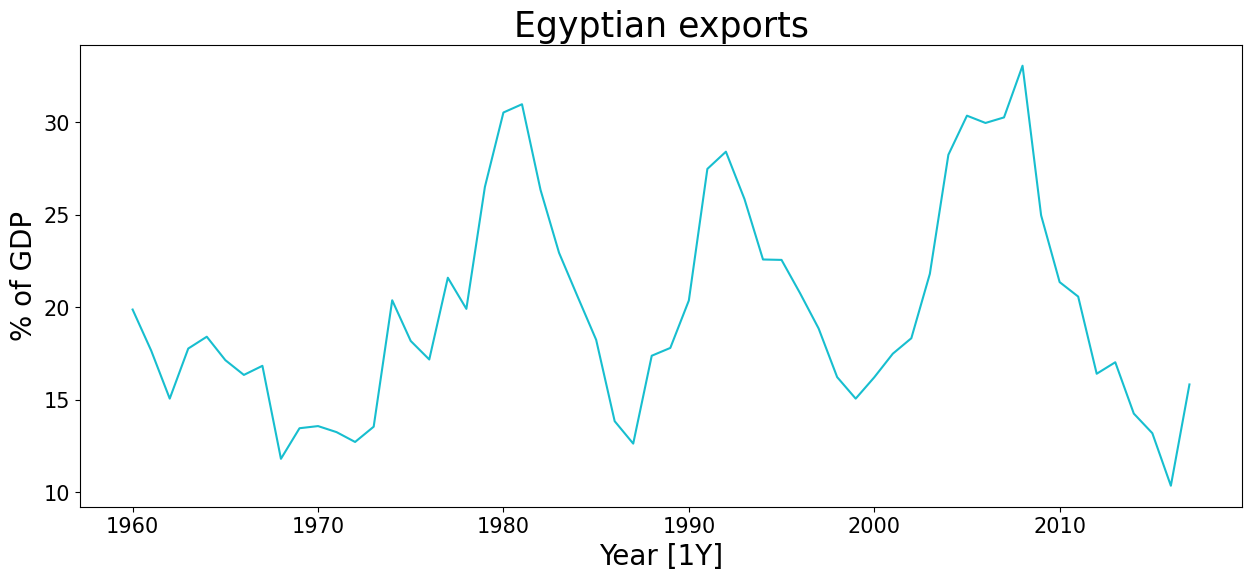

In [12]:
from fpppy.utils import plot_series

egyptian_economy = (
    pd.read_csv("../data/tsibbledata/global_economy.csv", parse_dates=["Year"])
    .loc[lambda x: x["Code"] == "EGY"]
    .rename(columns={"Year": "ds", "Exports": "y"})
    .assign(unique_id="Egypt")
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

plot_series(
    egyptian_economy,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Egyptian exports",
)

In [16]:
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast import StatsForecast

models = [AutoARIMA(allowmean=True)]
sf = StatsForecast(models=models, freq="YE", n_jobs=-1)
sf.fit(df=egyptian_economy)

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs["mean"] = coefs.pop("intercept")
coefs = {k: round(v, 3) for k, v in coefs.items()}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(2,0,1) with non-zero mean 

      Coefficients
ar1          1.676
ar2         -0.803
ma1         -0.690
mean        20.179 

         Metrics
sigma^2     8.05
loglik   -141.57
aic       293.13
aicc      294.29
bic       303.43


This is an ARIMA(2,0,1) model:

$y_t = c + 1.68y_{t-1} - 0.80y_{t-2} - 0.69\varepsilon_{t-1} + \varepsilon_t,$

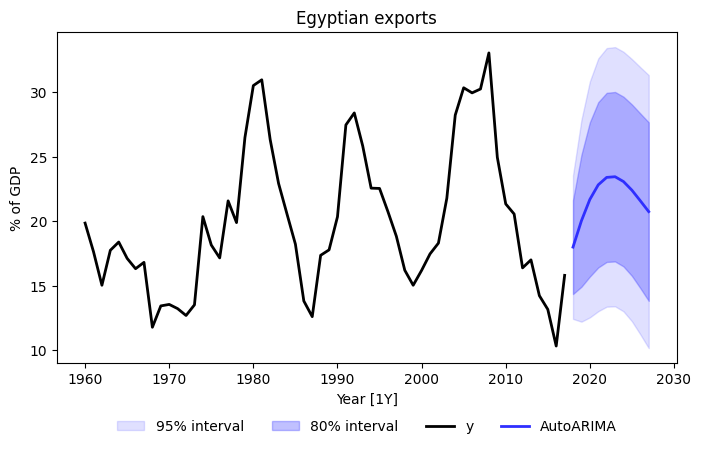

In [18]:
import matplotlib.pyplot as plt

levels = [80, 95]
fc = sf.predict(h=10, level=levels)

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-95"], fc["AutoARIMA-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    fc["ds"], fc["AutoARIMA-lo-80"], fc["AutoARIMA-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(
    egyptian_economy["ds"], egyptian_economy["y"],
    color="black", linewidth=2, label="y",
)
ax.plot(
    fc["ds"], fc["AutoARIMA"],
    color="#2f2fff", linewidth=2, label="AutoARIMA",
)

ax.set_title("Egyptian exports")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()

# 9.7 ARIMA modelling in statsforecast

In [22]:
caf_economy = (
    pd.read_csv("../data/tsibbledata/global_economy.csv", parse_dates=["Year"])
    .loc[lambda x: x["Code"] == "CAF"]
    .rename(columns={"Year": "ds", "Exports": "y"})
    .assign(unique_id="Central African Republic")
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

caf_economy.head()

,unique_id,ds,y
0,Central African Republic,1960-01-01,23.272724
1,Central African Republic,1961-01-01,26.490066
2,Central African Republic,1962-01-01,24.590165
3,Central African Republic,1963-01-01,25.236592
4,Central African Republic,1964-01-01,28.448269


/Users/omeraytug/Desktop/fpp3/.venv/lib/python3.13/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


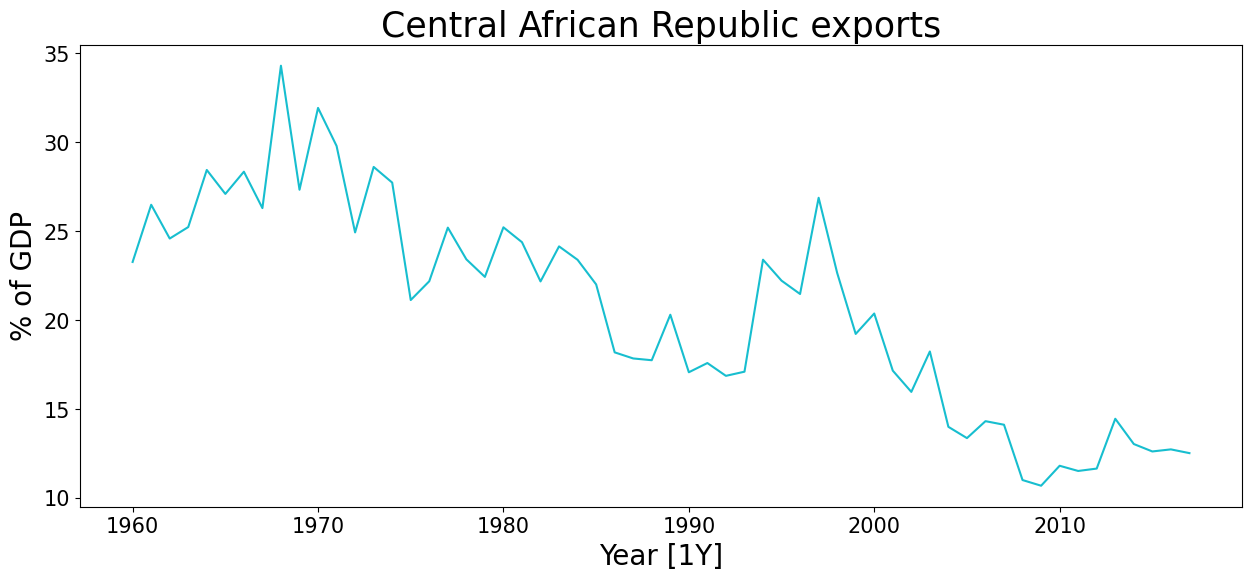

In [23]:
plot_series(caf_economy, xlabel="Year [1Y]", ylabel="% of GDP",
    title="Central African Republic exports")

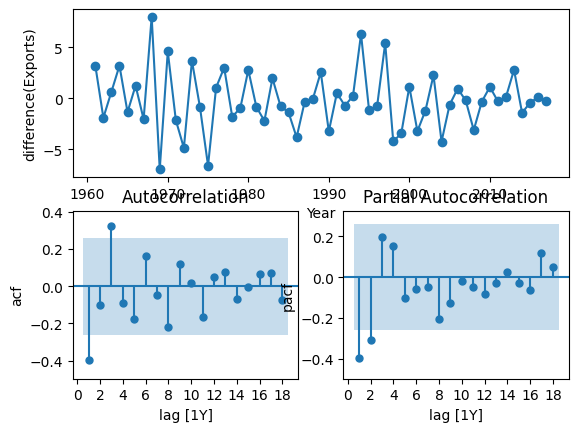

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = caf_economy.assign(diff=caf_economy["y"].diff()).iloc[1:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])

axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Year", ylabel="difference(Exports)")

plot_acf(
    df["diff"], ax=axes["acf"],
    zero=False, auto_ylims=True, bartlett_confint=False,
)
plot_pacf(
    df["diff"], ax=axes["pacf"],
    zero=False, auto_ylims=True,
)

axes["acf"].set(xlabel="lag [1Y]", ylabel="acf")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1Y]", ylabel="pacf")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [28]:
models = [
    ARIMA(order=(2, 1, 0), alias="arima210"),
    ARIMA(order=(0, 1, 3), alias="arima013"),
    AutoARIMA(alias="stepwise"),
    AutoARIMA(stepwise=False, alias="search"),
]
sf = StatsForecast(models=models, freq="YE", n_jobs=-1)
sf.fit(caf_economy)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,search,"ARIMA(3,1,0)",6.518527,-133.005829,274.011658,274.780889,282.183863
1,arima210,"ARIMA(2,1,0)",6.706196,-134.269488,274.538975,274.991805,280.668129
2,arima013,"ARIMA(0,1,3)",6.536673,-133.130383,274.260766,275.029997,282.432971
3,stepwise,"ARIMA(2,1,2)",6.416703,-132.124031,274.248061,275.424532,284.463317


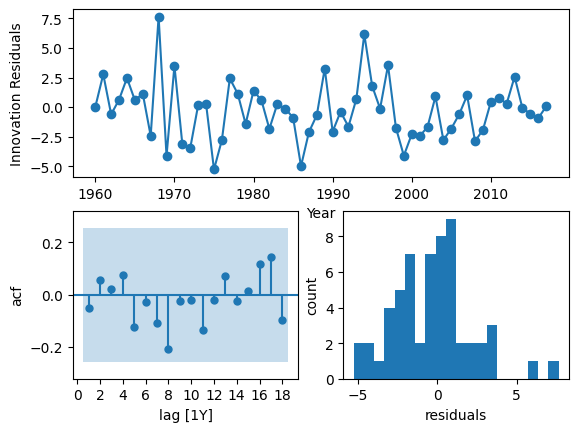

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from statsmodels.graphics.tsaplots import plot_acf

fc = sf.forecast(df=caf_economy, h=10, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["search"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(insample["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Year", ylabel="Innovation Residuals")

plot_acf(
    residuals, ax=axes["acf"],
    zero=False, auto_ylims=True, bartlett_confint=False,
)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf", title="")

axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [30]:
ljung_box = acorr_ljungbox(residuals, lags=[10], model_df=3)
ljung_box

,lb_stat,lb_pvalue
10,5.703851,0.574723


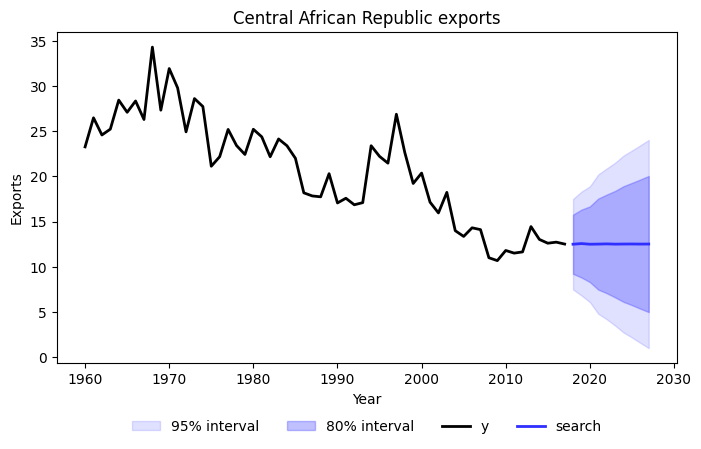

In [32]:
import matplotlib.pyplot as plt

search_columns = fc.columns[fc.columns.str.startswith("search")]
search_fc = fc[["unique_id", "ds", *search_columns]]

fig, ax = plt.subplots(figsize=(8, 4.3))

ax.fill_between(
    search_fc["ds"], search_fc["search-lo-95"], search_fc["search-hi-95"],
    color="#2f2fff", alpha=0.15, label="95% interval",
)
ax.fill_between(
    search_fc["ds"], search_fc["search-lo-80"], search_fc["search-hi-80"],
    color="#2f2fff", alpha=0.30, label="80% interval",
)
ax.plot(caf_economy["ds"], caf_economy["y"], color="black", linewidth=2, label="y")
ax.plot(search_fc["ds"], search_fc["search"], color="#2f2fff", linewidth=2, label="search")

ax.set_title("Central African Republic exports")
ax.set_xlabel("Year")
ax.set_ylabel("Exports")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.show()